In [18]:
import os

current_directory = os.getcwd()
print("Current Working Directory:", current_directory)


Current Working Directory: /scratch/nar8991/snn/snn_ann_hybrid


In [19]:
remapping = {
    "SNN": "SNN",
    "ANN_with_LIF_output": "ANN",
    "NSN_with_LIF_output": "Nonspiking",
    "Hybrid_RNN_SNN_rec": "SNN-ANN (Network-to-Network)",
    "Hybrid_NSN_SNN_rec": "SNN-Nonspiking (Network-to-Network)",
    "Hybrid_RNN_SNN_V1_same_layer": "SNN-ANN (Same Layer)",
    "Hybrid_NSN_SNN_V1_same_layer": "SNN-Nonspiking (Same Layer)",
    "old": "SNN (Evolutionary Team Implementation)",
}


In [20]:
# that might resemble actual weights (e.g., from a normal distribution)
import torch
import matplotlib.pyplot as plt
import numpy as np


def load_model(chosen_model):
    model_checkpoint_path = (
        f'optuna_results/{data}/{dim_manifold}_d/{num_classes}_classes/{nb_inputs}/'
        f'{loss_type}/{chosen_model}/recurrent_True/seed_{sweep_seed}/'
        f'{sampler_type}_sampler/{nb_hidden}_hidden/1.0_pct_data/best_model_of_study.ckpt'
    )

    model_class = MODEL_CLASSES.get(chosen_model)
    if model_class is None:
        raise ValueError(f"Unknown model name: {chosen_model}. Available: {list(MODEL_CLASSES.keys())}")


    print(f"Loading base model '{chosen_model}' from checkpoint: {model_checkpoint_path}")
    try:
        base_model_for_preprocessing = model_class.load_from_checkpoint(model_checkpoint_path)
        base_model_for_preprocessing.to(device) # Move to device for efficient inference
        base_model_for_preprocessing.eval()
        print("Base model loaded successfully for preprocessing.")
    except Exception as e:
        print(f"Error loading base model from checkpoint for preprocessing: {e}")
        raise RuntimeError(f"Failed to load base model: {e}")
    return base_model_for_preprocessing    
    
def load_and_visualize(chosen_model):

    base_model_for_preprocessing = load_model(chosen_model)

    w1_param = base_model_for_preprocessing.w1.data
    w2_param = base_model_for_preprocessing.w2.data
    v1_param = base_model_for_preprocessing.v1.data

    # Convert tensors to NumPy arrays for matplotlibƒ
    w1_np = w1_param.cpu().numpy()
    w2_np = w2_param.cpu().numpy()
    v1_np = v1_param.cpu().numpy()

    # --- Visualization ---

    # Set up the figure and subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 row, 3 columns for 3 plots
    fig.suptitle(f'Visualization of Model Weight Matrices {remapping[chosen_model]}', fontsize=16)

    # Plot w1
    ax1 = axes[0]
    im1 = ax1.imshow(w1_np, cmap='viridis', aspect='auto') # 'viridis' is a good perceptually uniform colormap
    ax1.set_title(f'w1 (Input to Hidden) | Shape: {w1_np.shape}')
    ax1.set_xlabel('Hidden Neurons (256)')
    ax1.set_ylabel('Input Features (700)')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04) # Add color bar

    # Plot w2
    ax2 = axes[1]
    im2 = ax2.imshow(w2_np, cmap='viridis', aspect='auto')
    ax2.set_title(f'w2 (Hidden to Output) | Shape: {w2_np.shape}')
    ax2.set_xlabel('Output Classes (20)')
    ax2.set_ylabel('Hidden Neurons (256)')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # Plot v1
    ax3 = axes[2]
    im3 = ax3.imshow(v1_np, cmap='viridis', aspect='auto')
    ax3.set_title(f'v1 (Recurrent Weights) | Shape: {v1_np.shape}')
    ax3.set_xlabel('Hidden Neurons (256)')
    ax3.set_ylabel('Hidden Neurons (256)')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


Using device: cuda
Loading base model 'Hybrid_RNN_SNN_rec' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_RNN_SNN_rec/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


/ext3/miniforge3/envs/py311_pflacco/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.


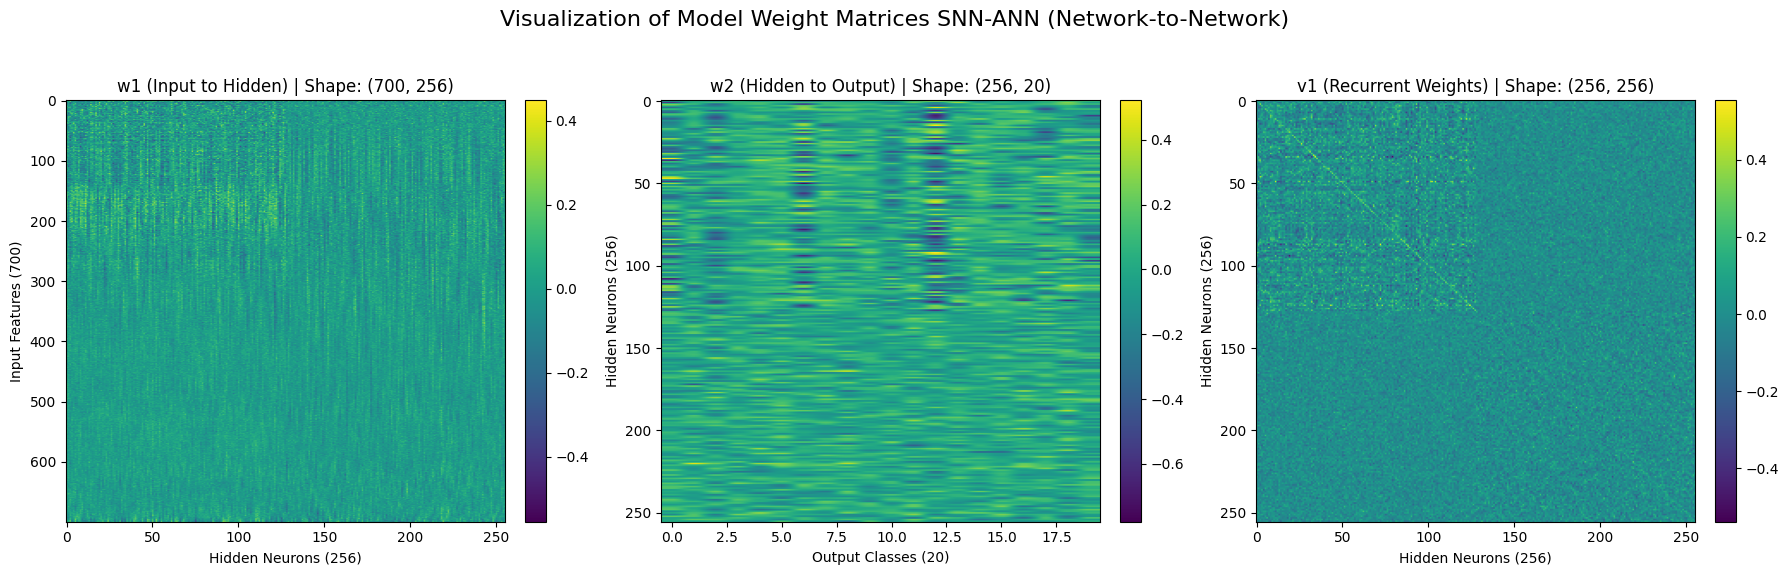

Loading base model 'Hybrid_RNN_SNN_V1_same_layer' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_RNN_SNN_V1_same_layer/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


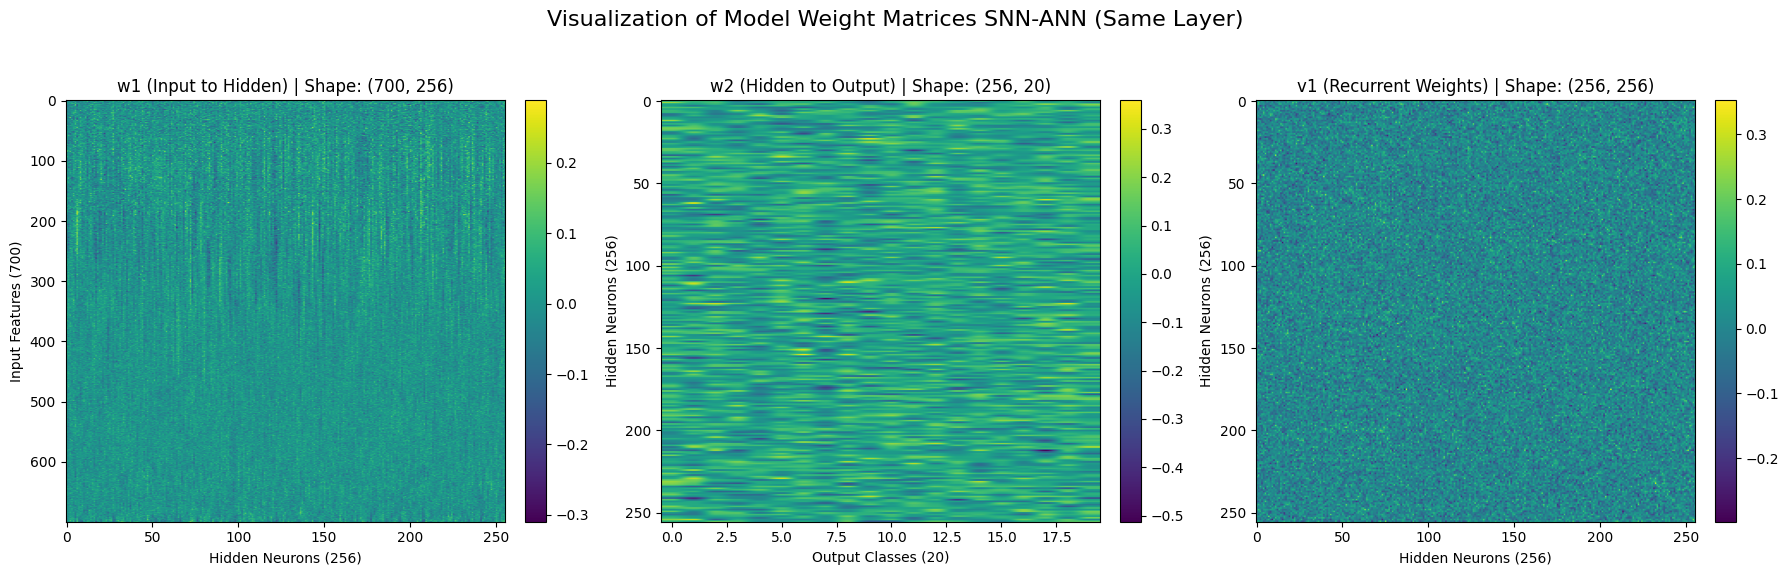

Loading base model 'Hybrid_NSN_SNN_rec' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_rec/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


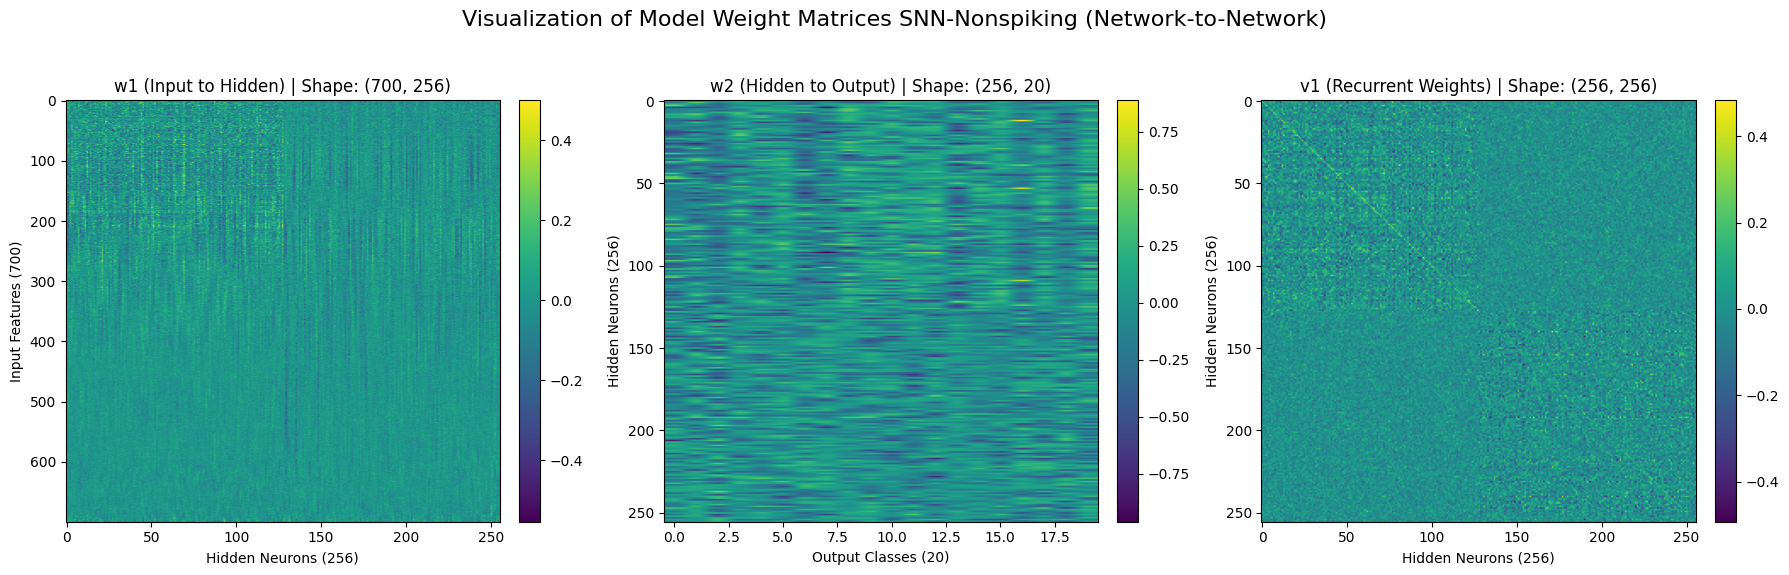

Loading base model 'Hybrid_NSN_SNN_V1_same_layer' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


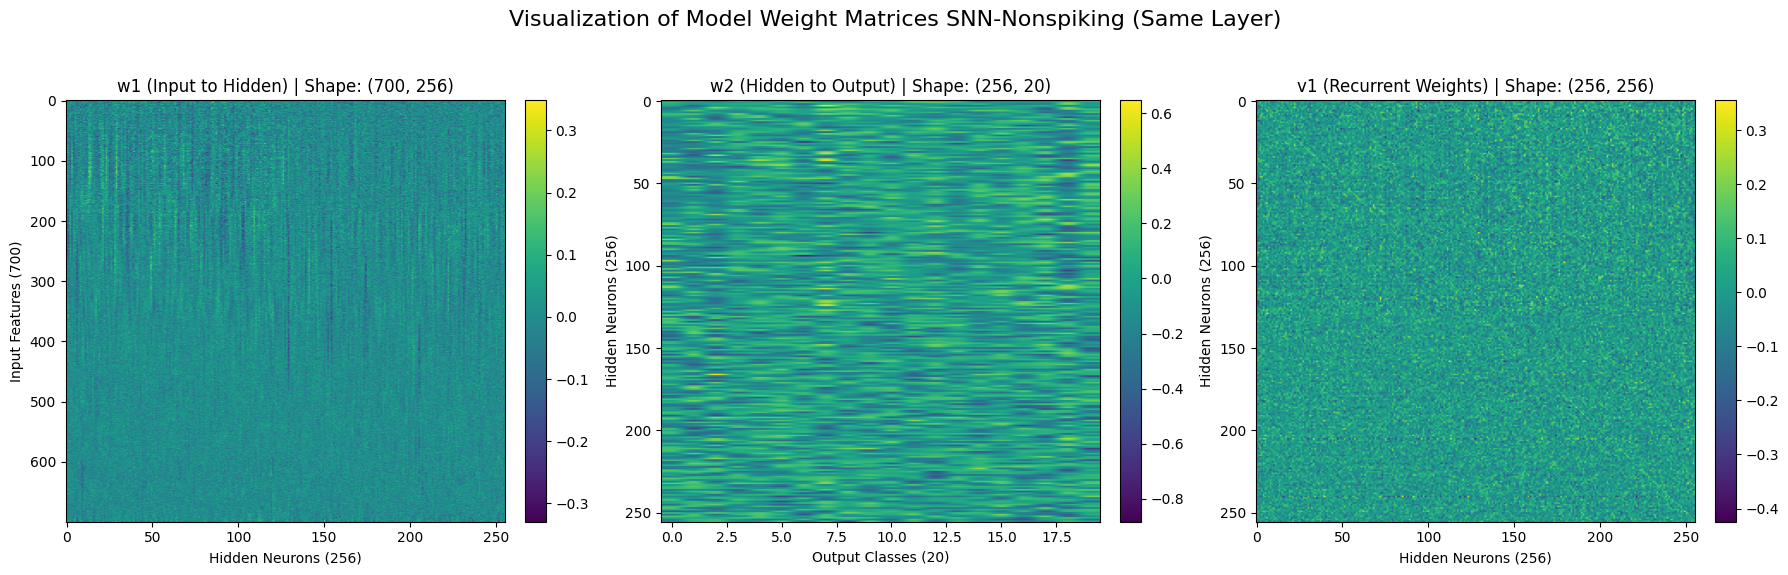

Loading base model 'ANN_with_LIF_output' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/ANN_with_LIF_output/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Note: spike_fn is generally not used for ANN hidden layers in this model. Only for LIF-like output if _apply_readout_layer were spiking, but it's not.
Base model loaded successfully for preprocessing.


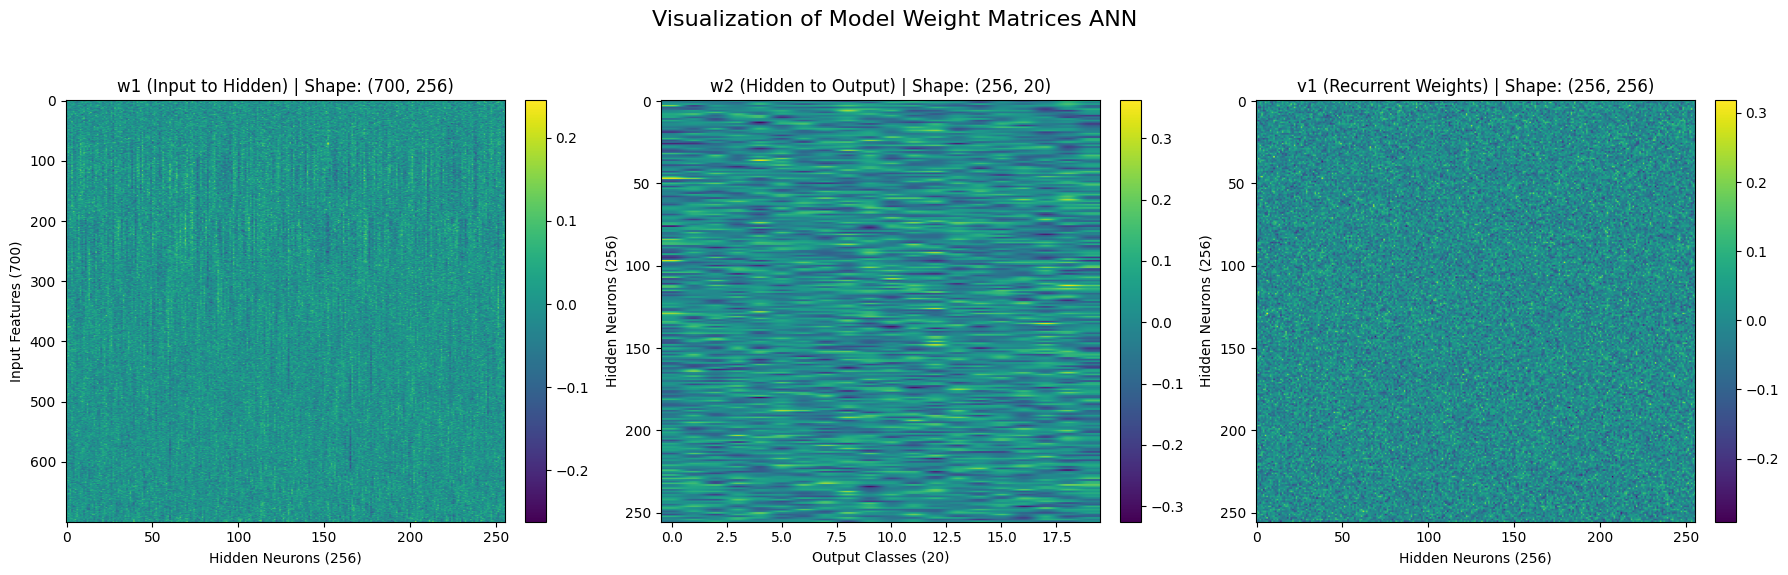

Loading base model 'NSN_with_LIF_output' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Note: spike_fn is generally not used for NSN hidden layers in this model. Only for LIF-like output if _apply_readout_layer were spiking, but it's not.
Base model loaded successfully for preprocessing.


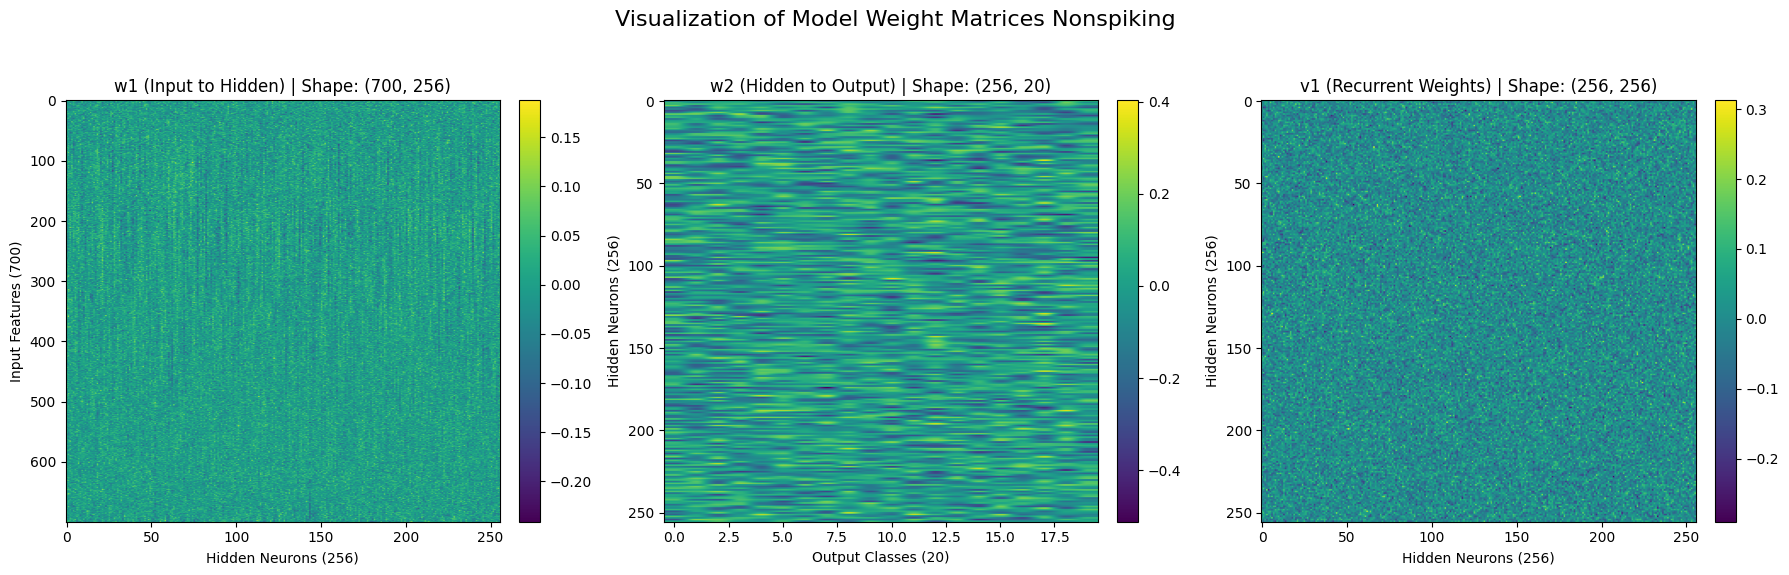

Loading base model 'SNN' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


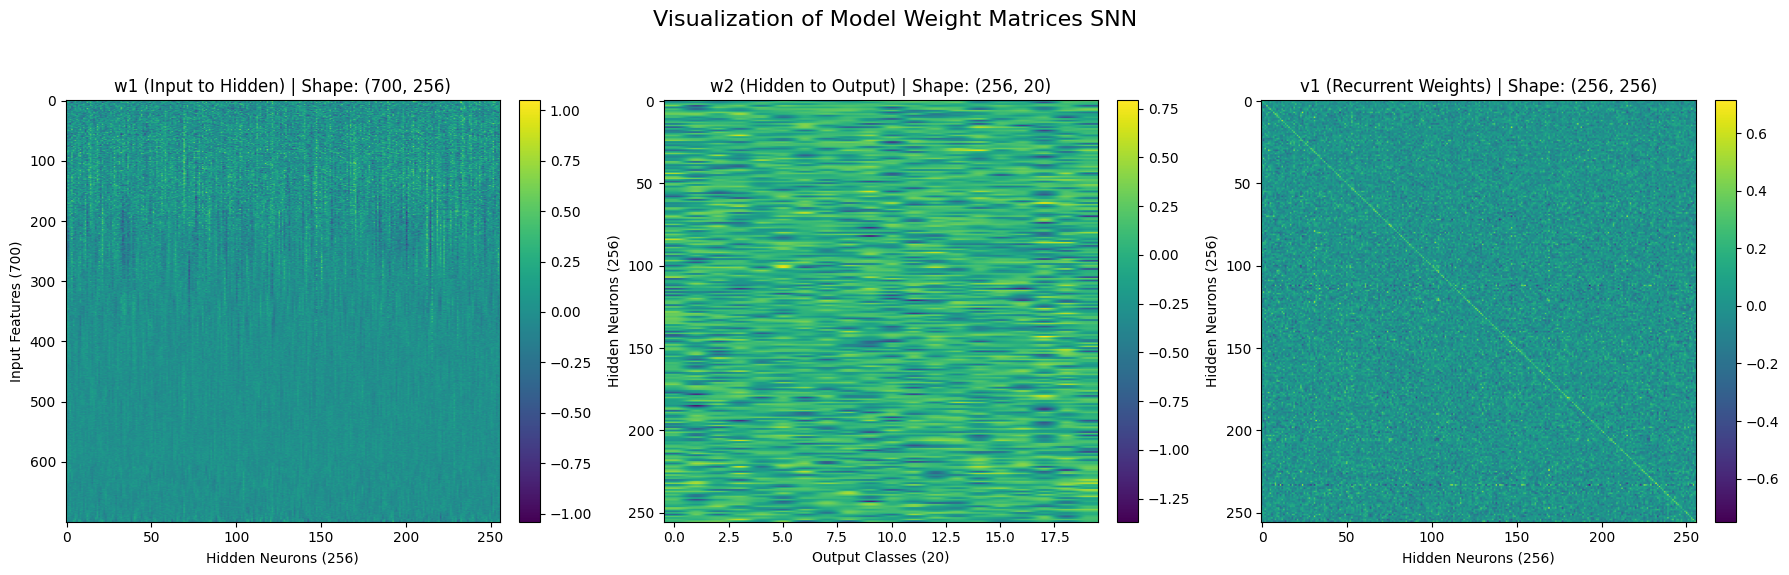

In [21]:
# Load a given model from /scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy
import torch 
from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too
sweep_seed = 1
chosen_models = ['Hybrid_RNN_SNN_rec', 'Hybrid_RNN_SNN_V1_same_layer', 'Hybrid_NSN_SNN_rec', 'Hybrid_NSN_SNN_V1_same_layer', 'ANN_with_LIF_output', 'NSN_with_LIF_output', 'SNN']

num_classes = 20
nb_inputs = 700
dim_manifold = None
data = 'shd'
loss_type = 'cross_entropy'
sampler_type = 'grid'
nb_hidden = 256


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

for chosen_model in chosen_models:
    load_and_visualize(chosen_model)

In [22]:
# Now let's get the dataset for saliency values

from maren_data.helpers import choose_data_params
import os
import json
data_config_path = f"data_construction/{data}_config.json"
# --- Load Data Configuration ---
if not os.path.exists(data_config_path):
    raise FileNotFoundError(f"Data config file not found at: {data_config_path}")
with open(data_config_path, 'r') as f:
    data_config = json.load(f)

settings = data_config.copy()
settings["device"] = device
settings["dtype"] = torch.float32
pre_path_data = f"/scratch/nar8991/snn/snn_ann_hybrid/maren_data/shd/{nb_inputs}_inputs/{data_config.get('max_time', 1.0)}_max_time/{data_config.get('noise', 0.0)}_noise"
_, _, test_loader = choose_data_params(
    data, settings, num_workers=2, pre_path=pre_path_data
)




choose data params for shd
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1.0 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([11])]
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1.0 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([10])]


Train class distribution: [364 352 361 381 348 364 354 352 352 365 368 363 376 364 370 391 380 385
 363 387]
Val class distribution: [42 49 43 26 45 35 46 48 43 41 43 49 36 49 48 30 35 27 47 34]
Test class distribution: [103 108 105 102 116 110 109 109 114 103 122 121 121 120 115 112 118 121
 123 112]


In [23]:
# Get saliency values on the hidden neuron level
import pytorch_lightning as pl
def get_saliency_values_neuron_level(model: pl.LightningModule, data_loader: torch.utils.data.DataLoader):
    """
    Compute saliency values for the combined hidden layer activations
    (hidden_out_combined_rec_tensor from BaseTemporalModel.forward),
    averaged across all samples and all time steps in the provided data loader.

    Args:
        model (pl.LightningModule): The trained PyTorch Lightning model (BaseTemporalModel instance).
        data_loader (torch.utils.data.DataLoader): DataLoader for temporal input samples.

    Returns:
        numpy.ndarray: An array of averaged saliency values for each neuron in the combined hidden layer output.
                       Shape will be (hidden_features,).
    """
    model.eval()  # Set the model to evaluation mode
    
    # List to store saliency maps for each sample
    all_neuron_saliency_maps_per_sample_time = []

    for inputs, targets in data_loader:
        # Move tensors to the appropriate device
        device = next(model.parameters()).device # Get model's device
        inputs = inputs.to(device)
        targets = targets.to(device)

        # We need to make sure the input requires gradients for the full forward pass
        inputs.requires_grad_(True)

        # Clear previous gradients for this batch
        model.zero_grad() 

        with torch.enable_grad(): # Ensure gradient tracking is on
            # Perform the full forward pass to get all outputs
            # We are interested in `hidden_activations_for_mine` and `predictions`
            predictions, auxiliary_outputs, _, hidden_activations_for_mine = model(inputs)
            
            # Get the logit_output as calculated in _common_step for loss calculation
            if model.max_logit:
                logit_output, _ = torch.max(predictions, dim=1) # (Batch, OutputFeatures)
            else:
                logit_output = torch.sum(predictions, dim=1) # (Batch, OutputFeatures)
            
            # Calculate the loss with respect to which we want gradients
            # Ensure targets are long() for CrossEntropyLoss if they aren't already
            loss_for_grad = model.loss_fn(logit_output, targets.long())

        # Compute gradients of the loss w.r.t. the combined hidden layer activations
        # hidden_activations_for_mine has shape (Batch, Time, HiddenFeatures)
        gradients_wrt_hidden_activations = torch.autograd.grad(
            outputs=loss_for_grad,
            inputs=hidden_activations_for_mine,
            create_graph=False, # Set to True if you need higher-order gradients
            retain_graph=False # No need to retain graph as we average immediately
        )[0] # Get the gradient tensor

        # Take the absolute value and average across the batch and time dimensions
        # This gives the average saliency for each neuron across the batch and all timesteps
        batch_time_saliency = gradients_wrt_hidden_activations.abs().mean(dim=[0, 1]) # Average over Batch and Time
        all_neuron_saliency_maps_per_sample_time.append(batch_time_saliency.cpu().numpy())

    # After iterating through all batches, average the collected batch-time saliency maps
    global_neuron_saliency = np.mean(all_neuron_saliency_maps_per_sample_time, axis=0)
    return global_neuron_saliency



Loading base model 'Hybrid_RNN_SNN_rec' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_RNN_SNN_rec/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the combined hidden layer output (averaged over time and test set):
[2.6681530e-06 2.6109187e-06 3.1859413e-06 2.4819244e-06 2.8581348e-06
 2.5998156e-06 2.9929399e-06 2.6360958e-06 2.4081855e-06 2.9510290e-06
 2.9633582e-06 3.0378174e-06 2.4381434e-06 2.9325174e-06 3.2023984e-06
 2.7030615e-06 2.6602090e-06 2.9959622e-06 3.0467763e-06 3.0029878e-06
 2.3680284e-06 2.6248533e-06 3.5458158e-06 3.8101850e-06 3.0493666e-06
 3.4192881e-06 3.8609701e-06 2.4895751e-06 3.2341484e-06 3.1823738e-06
 3.1450611e-06 3.9048409e-06 3.3488634e-06 3.4529824e-06 3.2023174e-06
 3.3724211e-06 3.6286381e-06 3.0296376e-06 2.6252619e-06 2.2379402e-06
 3.2704293e-06 3.2699927e-06 2.6228090e-06 3.3335875e-06 2.317011

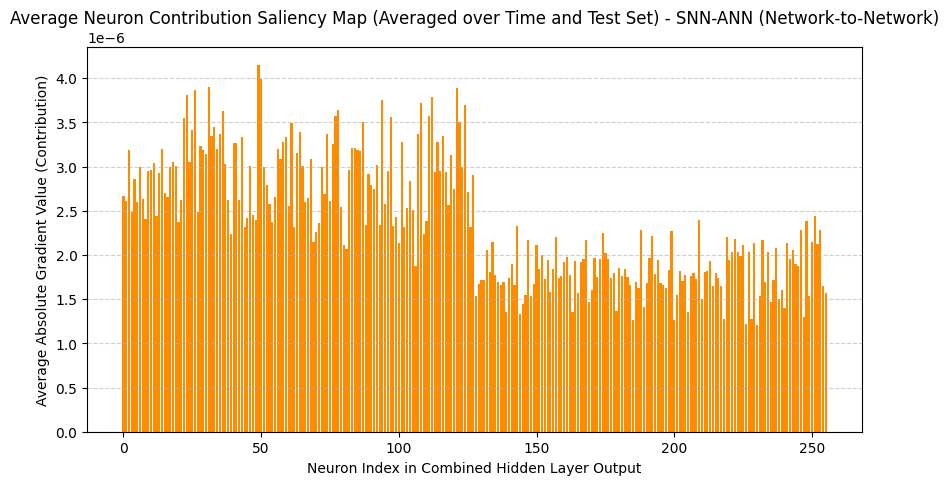


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'Hybrid_RNN_SNN_V1_same_layer' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_RNN_SNN_V1_same_layer/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the combined hidden layer output (averaged over time and test set):
[1.2713678e-06 1.4054147e-06 1.9298209e-06 1.2235573e-06 1.2073205e-06
 

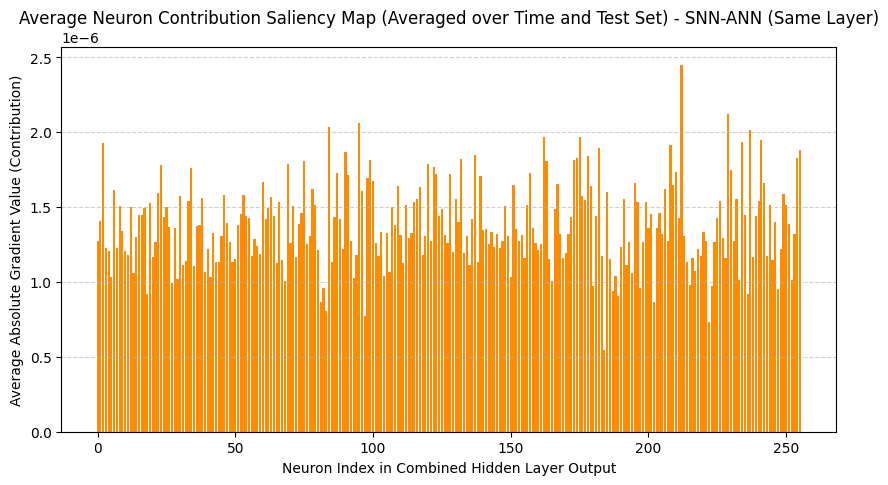


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'Hybrid_NSN_SNN_rec' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_rec/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.



Averages saliency for neurons in the combined hidden layer output (averaged over time and test set):
[3.7755167e-06 4.3202758e-06 2.3501118e-06 3.1518448e-06 4.6863229e-06
 2.8872248e-06 3.1889638e-06 3.3392494e-06 3.6870940e-06 2.6312746e-06
 3.0820645e-06 2.5068196e-06 5.5934611e-06 3.6235911e-06 4.3235291e-06
 2.8189122e-06 4.0082355e-06 3.5788669e-06 4.3014593e-06 4.3483228e-06
 4.0943687e-06 3.8376666e-06 3.2654627e-06 4.4295157e-06 4.0033087e-06
 3.6037256e-06 5.3132721e-06 3.1339143e-06 2.5142065e-06 3.7062314e-06
 3.5510429e-06 3.7599352e-06 2.6286007e-06 4.9096257e-06 3.3769029e-06
 4.3117129e-06 4.3849377e-06 2.8263466e-06 3.4934756e-06 5.5394230e-06
 3.6832275e-06 3.3851586e-06 3.4665973e-06 4.0225186e-06 4.3505188e-06
 4.4953999e-06 3.3368317e-06 2.6057485e-06 2.9742723e-06 4.0404211e-06
 3.3676388e-06 3.5195928e-06 3.0075309e-06 6.6444372e-06 2.5568229e-06
 2.9050550e-06 4.4243197e-06 3.1589680e-06 4.2535339e-06 3.0926685e-06
 4.3652512e-06 4.1382450e-06 3.7033044e-06 3.4

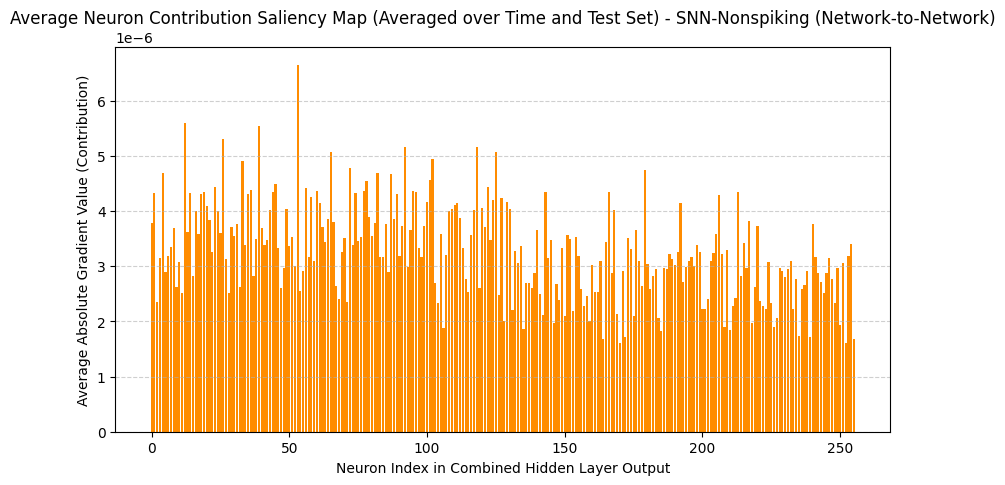


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'Hybrid_NSN_SNN_V1_same_layer' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the combined hidden layer output (averaged over time and test set):
[2.3805030e-06 1.0207131e-06 1.3649266e-06 1.7644949e-06 1.7493899e-06
 

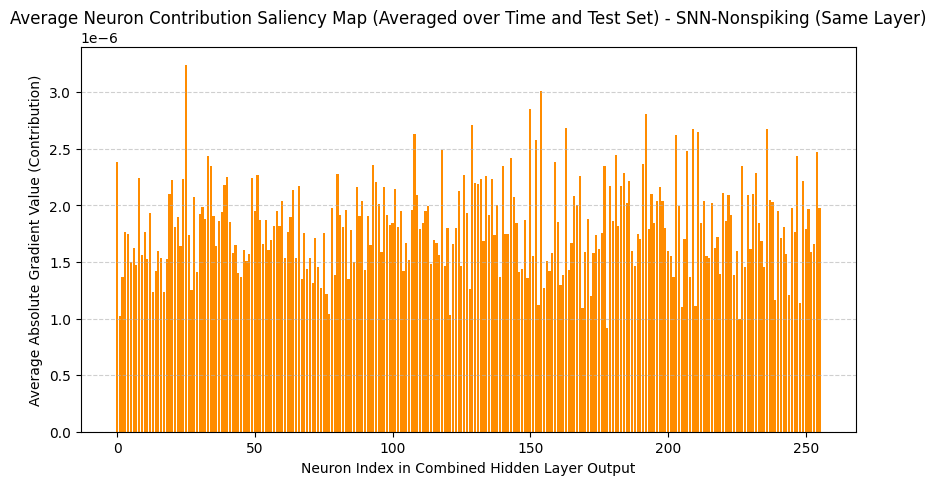


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'ANN_with_LIF_output' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/ANN_with_LIF_output/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Note: spike_fn is generally not used for ANN hidden layers in this model. Only for LIF-like output if _apply_readout_layer were spiking, but it's not.
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the com

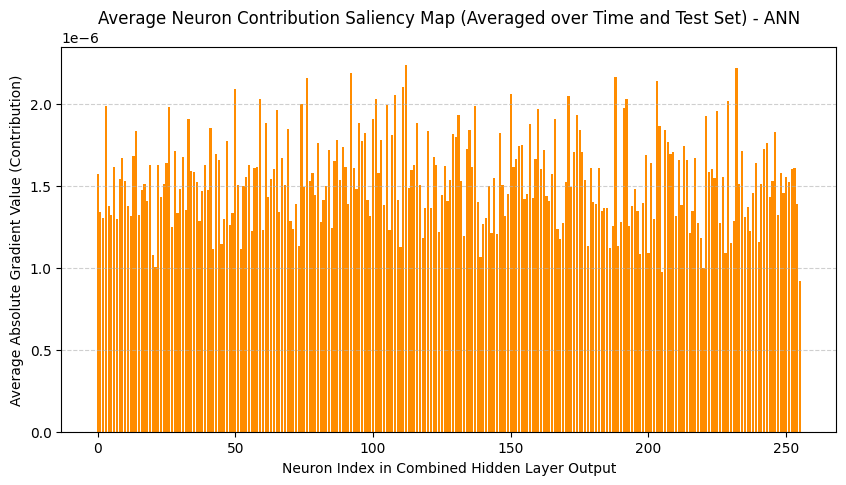


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'NSN_with_LIF_output' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Note: spike_fn is generally not used for NSN hidden layers in this model. Only for LIF-like output if _apply_readout_layer were spiking, but it's not.
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the com

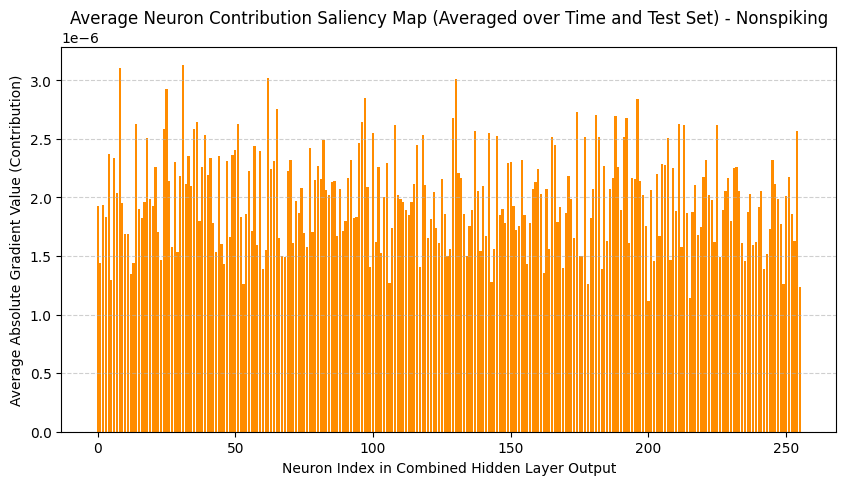


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 
Loading base model 'SNN' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.

Averages saliency for neurons in the combined hidden layer output (averaged over time and test set):
[3.1031184e-06 2.7397750e-06 1.3642751e-06 4.3864652e-06 3.2026719e-06
 3.6811118e-06 2.7513795e-06 3.3987012e-06 3.043154

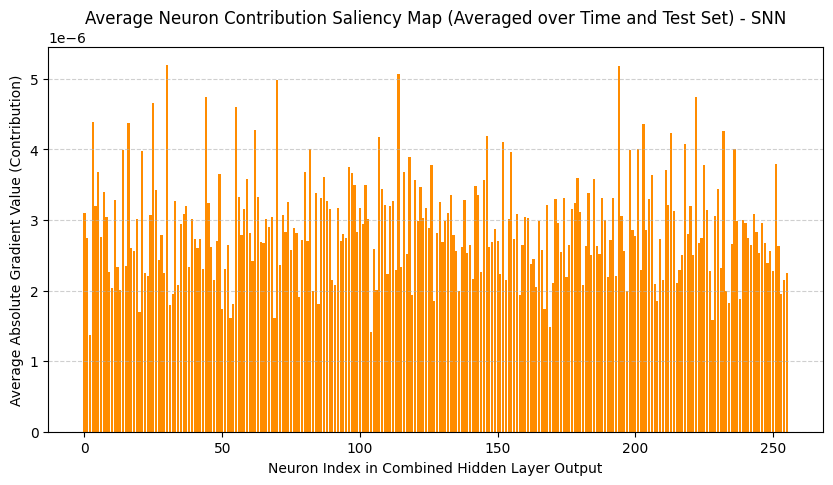


--- Interpretation of Averaged Neuron Saliency ---
Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).
The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.
A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. 


In [24]:
def plot_saliency_values(chosen_model):
    model = load_model(chosen_model)
    averaged_saliency_base_model = get_saliency_values_neuron_level(model, test_loader)

    print(f"\nAverages saliency for neurons in the combined hidden layer output (averaged over time and test set):\n{averaged_saliency_base_model}")

    # 5. Visualize the Averaged Saliency Map
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(averaged_saliency_base_model)), averaged_saliency_base_model, color='darkorange')
    plt.xlabel('Neuron Index in Combined Hidden Layer Output')
    plt.ylabel('Average Absolute Gradient Value (Contribution)')
    plt.title(f'Average Neuron Contribution Saliency Map (Averaged over Time and Test Set) - {remapping[chosen_model]}')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    print("\n--- Interpretation of Averaged Neuron Saliency ---")
    print("Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).")
    print("The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.")
    print("A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. ")

for chosen_model in chosen_models:
    plot_saliency_values(chosen_model)

In [62]:
from tqdm import tqdm
import torch
import numpy as np

def get_conductance_values_from_hidden(
    model: pl.LightningModule,
    data_loader: torch.utils.data.DataLoader,
    num_steps: int = 5,
    mini_batch_size: int = 5,  # max size per mini-batch chunk
    baseline_fn=None,
):
    model.eval()
    device = next(model.parameters()).device
    all_conductance_maps = []

    with torch.no_grad():
        for inputs, targets in tqdm(data_loader, desc="Batches"):
            batch_size = inputs.shape[0]
            inputs = inputs.to(device)
            targets = targets.to(device)

            baseline = (
                baseline_fn(inputs).to(device) if baseline_fn is not None else torch.zeros_like(inputs)
            )
            direction = (inputs - baseline).detach()

            microbatch_conductances = []

            # Split batch into mini-batches to save memory
            for start_idx in range(0, batch_size, mini_batch_size):
                end_idx = min(start_idx + mini_batch_size, batch_size)

                inputs_mb = inputs[start_idx:end_idx]
                targets_mb = targets[start_idx:end_idx]
                baseline_mb = baseline[start_idx:end_idx]
                direction_mb = direction[start_idx:end_idx]
                B = inputs_mb.shape[0]

                integrated_sum = None

                for i in range(num_steps):
                    alpha = (i + 0.5) / num_steps
                    x_alpha = baseline_mb + alpha * direction_mb
                    x_alpha.requires_grad_(True)

                    with torch.enable_grad():
                        predictions, _, _, acts = model(x_alpha)
                        acts_reduced = acts.mean(dim=1)  # average over time
                        num_neurons = acts_reduced.shape[1]
                        acts_flat = acts_reduced.view(B, num_neurons)

                        Fx, _ = torch.max(predictions, dim=1)
                        Fx_mean = Fx.mean()

                        dF_dy = torch.autograd.grad(
                            Fx_mean, acts_flat, retain_graph=False, create_graph=False, allow_unused=True
                        )[0]

                        if dF_dy is None:
                            dF_dy = torch.zeros_like(acts_flat)

                        def acts_fn(inp):
                            _, _, _, a = model(inp)
                            a_reduced = a.mean(dim=1)
                            return a_reduced.view(B, num_neurons)

                        _, dy_dx_dir = torch.autograd.functional.jvp(
                            acts_fn,
                            (x_alpha,),
                            (direction_mb,),
                            create_graph=False,
                        )
                        dy_dx_dir = dy_dx_dir.view(B, num_neurons)

                        integrand = dF_dy * dy_dx_dir

                        if integrated_sum is None:
                            integrated_sum = integrand
                        else:
                            integrated_sum += integrand

                    del x_alpha, predictions, acts, acts_reduced, acts_flat, Fx, Fx_mean, dF_dy, dy_dx_dir, integrand
                    torch.cuda.empty_cache()

                integrated_sum /= num_steps
                conductance_vals = integrated_sum.mean(dim=0)  # shape (num_neurons,)
                microbatch_conductances.append(conductance_vals.detach().cpu().numpy())

                del inputs_mb, targets_mb, baseline_mb, direction_mb, integrated_sum, conductance_vals
                torch.cuda.empty_cache()

            # Average across all mini-batches of this batch
            batch_conductance = np.mean(microbatch_conductances, axis=0)
            all_conductance_maps.append(batch_conductance)

            del inputs, targets, baseline, direction
            torch.cuda.empty_cache()

    return np.mean(all_conductance_maps, axis=0)


In [ ]:
# import torch
# import numpy as np
# from tqdm import tqdm
# from captum.attr import IntegratedGradients

# def get_conductance_values_from_hidden_captum(
#     model: torch.nn.Module,
#     data_loader: torch.utils.data.DataLoader,
#     num_steps: int = 50,
#     baseline_fn=None
# ):
#     """
#     Computes conductance for the hidden_out_combined_rec_tensor using Captum's IntegratedGradients.
#     The conductance formula is from 'How Important is a Neuron?' Eq. 3.
#     """

#     model.eval()
#     device = next(model.parameters()).device
#     print(f"Model device: {device}")
#     all_conductance_maps = []

#     # Forward function that starts from *input*, returns scalar loss
#     # but also captures hidden activations
#     def forward_with_hidden(x, targets):
#         predictions, _, _, acts = model(x)  # acts = hidden_out_combined_rec_tensor
#         # We'll return the loss, but also save acts in closure scope
#         logit_output, _ = torch.max(predictions, dim=1)
#         loss = model.loss_fn(logit_output, targets)
#         return loss, acts

#     # We'll use this inner function for Captum — it only returns loss (scalar),
#     # but we capture acts via a hook
#     captured_acts = {}

#     def loss_only_forward(x, targets):
#         loss, acts = forward_with_hidden(x, targets)
#         captured_acts["acts"] = acts
#         return loss

#     ig = IntegratedGradients(loss_only_forward)

#     for inputs, targets in tqdm(data_loader, desc="Batches"):
#         inputs = inputs.to(device)
#         targets = targets.to(device)

#         if baseline_fn is None:
#             baseline = torch.zeros_like(inputs)
#         else:
#             baseline = baseline_fn(inputs).to(device)

#         # Run Captum IG — we pass targets as additional_forward_args
#         _ = ig.attribute(
#             inputs=inputs,
#             baselines=baseline,
#             additional_forward_args=(targets,),
#             n_steps=num_steps
#         )

#         # After IG call, acts from *last forward* are in captured_acts
#         acts_actual = captured_acts["acts"]  # shape (B, ..., neurons)
#         acts_baseline = torch.zeros_like(acts_actual)

#         # Now compute conductance: attribution * (acts_actual - acts_baseline)
#         # Captum doesn't give us attribution w.r.t. acts directly,
#         # so we backprop IG w.r.t. activations using the saved acts

#         # Get attribution for acts
#         def loss_from_acts(a, targets):
#             # Replace activations in forward pass with `a`
#             # NOTE: requires a forward method variant if we don't use hooks
#             # For now, re-run model with inputs to get predictions — simplified
#             preds, _, _, _ = model(inputs)  # same as before
#             logit_output, _ = torch.max(preds, dim=1)

#             return model.loss_fn(preds, targets)

#         ig_acts = IntegratedGradients(loss_from_acts)
#         attr_acts = ig_acts.attribute(
#             inputs=acts_actual,
#             baselines=acts_baseline,
#             additional_forward_args=(targets,),
#             n_steps=num_steps
#         )

#         diff_acts = acts_actual - acts_baseline
#         conductance_vals = (attr_acts * diff_acts).sum(dim=0).mean(dim=0)  # per neuron
#         all_conductance_maps.append(conductance_vals.detach().cpu().numpy())

#     return np.mean(all_conductance_maps, axis=0)


In [63]:
import torch
torch.cuda.empty_cache()

def plot_conductance_values(chosen_model):
    model = load_model(chosen_model)
    averaged_saliency_base_model = get_conductance_values_from_hidden(model, test_loader, num_steps=2)

    print(f"\nAverages conductance for neurons in the combined hidden layer output (averaged over time and test set):\n{averaged_saliency_base_model}")

    # 5. Visualize the Averaged Saliency Map
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(averaged_saliency_base_model)), averaged_saliency_base_model, color='darkorange')
    plt.xlabel('Neuron Index in Combined Hidden Layer Output')
    plt.ylabel('Average Absolute Gradient Value (Contribution)')
    plt.title(f'Average Neuron Conductance Map (Averaged over Time and Test Set) - {remapping[chosen_model]}')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    print("\n--- Interpretation of Averaged Neuron Saliency ---")
    print("Each bar represents a neuron in the combined hidden layer output (after SNN/ANN processing for all time steps).")
    print("The height of the bar shows the average absolute gradient of the loss with respect to that neuron's activation, averaged across all samples and all time steps in the data loader.")
    print("A taller bar indicates that, on average, a neuron in this hidden layer consistently has a stronger influence on the model's loss (and thus its predictions) over the entire temporal dataset subset. ")

for chosen_model in chosen_models:
    plot_conductance_values(chosen_model)

Loading base model 'Hybrid_RNN_SNN_rec' from checkpoint: optuna_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_RNN_SNN_rec/recurrent_True/seed_1/grid_sampler/256_hidden/1.0_pct_data/best_model_of_study.ckpt
Base model loaded successfully for preprocessing.


Batches:   0%|          | 0/9 [00:02<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 342.00 MiB. GPU 0 has a total capacity of 44.48 GiB of which 323.31 MiB is free. Including non-PyTorch memory, this process has 44.16 GiB memory in use. Of the allocated memory 35.50 GiB is allocated by PyTorch, and 8.46 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
torch.cuda.memory_summary()

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 3            |        cudaMalloc retries: 4         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |  44075 MiB |  44078 MiB |   1054 GiB |   1011 GiB |\n|       from large pool |  44072 MiB |  44072 MiB |    827 GiB |    784 GiB |\n|       from small pool |      3 MiB |   2132 MiB |    227 GiB |    227 GiB |\n|---------------------------------------------------------------------------|\n| Active memory         |  44075 MiB |  44078 MiB |   1054 GiB |   1011 GiB |\n|       from large pool |  44072 MiB |  44072 MiB |

In [ ]:
torch.cuda.empty_cache() 